In [15]:
import sympy as sp

# --- symbols ---
s = sp.Symbol('s')
k3, k4, k5, k7 = sp.symbols('k3 k4 k5 k7', positive=True)
u1, u2 = sp.symbols('u1 u2', positive=True)

# equilibrium symbols (we will express these too)
Xst = sp.Symbol('Xst', positive=True)
Z1st = sp.Symbol('Z1st', positive=True)
Z3st = sp.Symbol('Z3st', positive=True)

# --- define steady-state relations for network B ---
# 1) X* = 3 u1 / k3  (from integrator identity)
Xst_expr = 3*u1/k3

# 2) Z1* from X equation using k7 Z1 Z3 = 3 u1 and X*
Z1st_expr = ((u2+k3)*Xst_expr + k5*Xst_expr**2 - 3*u1)/k4

# 3) Z3* from product constraint Z1* Z3* = 3 u1 / k7
Z3st_expr = (3*u1/k7)/Z1st_expr

# --- Jacobian A at equilibrium ---
A = sp.Matrix([
    [-(u2+k3) - 2*k5*Xst,     k4 + k7*Z3st,      k7*Z1st],
    [0,                      -k7*Z3st,         -k7*Z1st],
    [k3,                     -k7*Z3st,         -k7*Z1st]
])

# --- define output y = X and controller output u_c = k4 Z1 + k7 Z1 Z3 ---
Cy = sp.Matrix([[1, 0, 0]])
Cu = sp.Matrix([[0, k4 + k7*Z3st, k7*Z1st]])

# --- choose reference input r with k3 r = 3 u1 ---
# using r as input => delta r enters Z1 equation as +k3 delta r
B = sp.Matrix([0, k3, 0])

# --- Method 1 effective A matrix ---
Ae = A + B*Cy  # (3x1)*(1x3) => 3x3

# --- transfer function G_ce(s) = Cu (sI - Ae)^(-1) B ---
I = sp.eye(3)
Gce = sp.simplify((Cu * (s*I - Ae).inv() * B)[0])

# substitute equilibrium expressions if you want a reduced symbolic expression
Gce_sub = sp.simplify(Gce.subs({Xst: Xst_expr, Z1st: Z1st_expr, Z3st: Z3st_expr}))

print("G_ce(s) =")
print(Gce_sub)

import sympy as sp

# Make it a single rational function P/Q
G = sp.together(Gce_sub)     # usually much cheaper than simplify()
P, Q = sp.fraction(G)        # numerator/denominator

# (optional but often helps) cancel common factors
P, Q = sp.cancel(P/Q).as_numer_denom()

# Check integrator pole at s=0
Q0 = sp.simplify(Q.subs(s, 0))
# Expect Q0 == 0 for I-action

# Derivatives at 0
P0  = sp.simplify(P.subs(s, 0))
P1  = sp.simplify(sp.diff(P, s).subs(s, 0))

Q1  = sp.simplify(sp.diff(Q, s).subs(s, 0))           # Q'(0)
Q2  = sp.simplify(sp.diff(Q, s, 2).subs(s, 0) / 2)     # Q''(0)/2

Ki = sp.simplify(P0 / Q1)
Kp = sp.simplify((P1*Q1 - P0*Q2) / (Q1**2))

print("Q(0) =", Q0)
print("Ki =", Ki)
print("Kp =", Kp)

Kd = sp.simplify(sp.diff(Gce_sub - Ki/s - Kp, s).subs(s, 0))
print("Kd =", Kd)


G_ce(s) =
k3*k4*(-3*k3**2*k7*u1*(-k3**2 + k3*(k3 + u2) + 3*k5*u1)*(k3**2 + k3*s + k3*u2 - k3*(k3 + u2) + 3*k5*u1) + (k3*(k3 + u2) + 3*k5*u1)*(k3**3*k4*s*(k3 + s + u2) + 6*k3**2*k4*k5*s*u1 + 3*k3*k7*u1*(s + u2)*(-k3**2 + k3*(k3 + u2) + 3*k5*u1) + 18*k5*k7*u1**2*(-k3**2 + k3*(k3 + u2) + 3*k5*u1)))/(s*(k3**4*k4**2*(k3*s + k3*u2 + 6*k5*u1) + k3**3*k4*(-k3**2 + k3*(k3 + u2) + 3*k5*u1)*(-k3*k4 + k3*s + s**2 + s*u2) + 6*k3**2*k4*k5*s*u1*(-k3**2 + k3*(k3 + u2) + 3*k5*u1) + 3*k3*k7*u1*(s + u2)*(-k3**2 + k3*(k3 + u2) + 3*k5*u1)**2 + 18*k5*k7*u1**2*(-k3**2 + k3*(k3 + u2) + 3*k5*u1)**2))
Q(0) = 0
Ki = k3*k4*k7*(k3**4*u2**2 + 6*k3**3*k5*u1*u2 + k3**3*u2**3 + 9*k3**2*k5**2*u1**2 + 12*k3**2*k5*u1*u2**2 + 45*k3*k5**2*u1**2*u2 + 54*k5**3*u1**3)/(k3**4*k4**2*k5 + k3**3*k7*u2**3 + 12*k3**2*k5*k7*u1*u2**2 + 45*k3*k5**2*k7*u1**2*u2 + 54*k5**3*k7*u1**3)
Kp = k3**2*k4*(-k7*(k3**4*u2**2 + 6*k3**3*k5*u1*u2 + k3**3*u2**3 + 9*k3**2*k5**2*u1**2 + 12*k3**2*k5*u1*u2**2 + 45*k3*k5**2*u1**2*u2 + 54*k5**3*u1**3)*(k3**

In [30]:
import sympy as sp

s = sp.Symbol('s')
I = sp.eye(3)

# Bu, A, Cy, Cu already defined by you
# Bu = sp.Matrix([0, 3, 0])
# Cy = sp.Matrix([[1,0,0]])

Ae = A + B*Cy   # use A - Bu*Cy only if you defined e = y - r

# Solve (sI - Ae) X = Bu  => X = (sI - Ae)^(-1) Bu without forming the inverse
X = (s*I - Ae).LUsolve(B)

Gce = sp.together((Cu*X)[0])  # scalar transfer function
Gce = sp.cancel(Gce)          # cancel common factors

print(Gce)


(2*Xst*Z1st*k3*k4*k5*k7 + 2*Xst*Z3st*k3*k5*k7*s + 2*Xst*k3*k4*k5*s + Z1st*k3**2*k4*k7 + Z1st*k3*k4*k7*s + Z1st*k3*k4*k7*u2 + Z3st*k3**2*k7*s + Z3st*k3*k7*s**2 + Z3st*k3*k7*s*u2 + k3**2*k4*s + k3*k4*s**2 + k3*k4*s*u2)/(2*Xst*Z1st*k5*k7*s + 2*Xst*Z3st*k5*k7*s + 2*Xst*k5*s**2 + Z1st*k7*s**2 + Z1st*k7*s*u2 + Z3st*k7*s**2 + Z3st*k7*s*u2 - k3*k4*s + k3*s**2 + s**3 + s**2*u2)


In [31]:
import sympy as sp

s = sp.Symbol('s')

G = sp.together(G)          # ensure single fraction
G = sp.cancel(G)            # cancel common factors (important)
P, Q = sp.fraction(G)       # numerator, denominator

# Make them polynomials in s
Ppoly = sp.Poly(P, s)
Qpoly = sp.Poly(Q, s)

print("Numerator degree:", Ppoly.degree())
print("Denominator degree:", Qpoly.degree())

# Display as coefficients
print("Numerator coeffs (highest -> lowest):", Ppoly.all_coeffs())
print("Denominator coeffs (highest -> lowest):", Qpoly.all_coeffs())

Numerator degree: 2
Denominator degree: 3
Numerator coeffs (highest -> lowest): [k3**6*k4**2 + k3**5*k4**2*u2 + 3*k3**4*k4**2*k5*u1, k3**7*k4**2 + 2*k3**6*k4**2*u2 + 9*k3**5*k4**2*k5*u1 + k3**5*k4**2*u2**2 + 9*k3**4*k4**2*k5*u1*u2 + 3*k3**4*k4*k7*u1*u2**2 + 18*k3**3*k4**2*k5**2*u1**2 + 18*k3**3*k4*k5*k7*u1**2*u2 + 27*k3**2*k4*k5**2*k7*u1**3, 3*k3**5*k4*k7*u1*u2**2 + 18*k3**4*k4*k5*k7*u1**2*u2 + 3*k3**4*k4*k7*u1*u2**3 + 27*k3**3*k4*k5**2*k7*u1**3 + 36*k3**3*k4*k5*k7*u1**2*u2**2 + 135*k3**2*k4*k5**2*k7*u1**3*u2 + 162*k3*k4*k5**3*k7*u1**4]
Denominator coeffs (highest -> lowest): [k3**4*k4*u2 + 3*k3**3*k4*k5*u1, k3**5*k4**2 + k3**5*k4*u2 + 3*k3**4*k4*k5*u1 + k3**4*k4*u2**2 + 9*k3**3*k4*k5*u1*u2 + 3*k3**3*k7*u1*u2**2 + 18*k3**2*k4*k5**2*u1**2 + 18*k3**2*k5*k7*u1**2*u2 + 27*k3*k5**2*k7*u1**3, 3*k3**4*k4**2*k5*u1 + 3*k3**3*k7*u1*u2**3 + 36*k3**2*k5*k7*u1**2*u2**2 + 135*k3*k5**2*k7*u1**3*u2 + 162*k5**3*k7*u1**4, 0]


In [ ]:
Qfact = sp.factor(Q)
print("Denominator factored:")
sp.pprint(Qfact)

Denominator factored:
  ⎛  5   2       5               4   2             4                4     2    ↪
s⋅⎝k₃ ⋅k₄ ⋅s + k₃ ⋅k₄⋅s⋅u₂ + 3⋅k₃ ⋅k₄ ⋅k₅⋅u₁ + 3⋅k₃ ⋅k₄⋅k₅⋅s⋅u₁ + k₃ ⋅k₄⋅s ⋅u₂ ↪

↪      4        2       3        2          3                     3            ↪
↪  + k₃ ⋅k₄⋅s⋅u₂  + 3⋅k₃ ⋅k₄⋅k₅⋅s ⋅u₁ + 9⋅k₃ ⋅k₄⋅k₅⋅s⋅u₁⋅u₂ + 3⋅k₃ ⋅k₇⋅s⋅u₁⋅u₂ ↪

↪ 2       3         3        2      2     2        2           2           2   ↪
↪   + 3⋅k₃ ⋅k₇⋅u₁⋅u₂  + 18⋅k₃ ⋅k₄⋅k₅ ⋅s⋅u₁  + 18⋅k₃ ⋅k₅⋅k₇⋅s⋅u₁ ⋅u₂ + 36⋅k₃ ⋅k ↪

↪        2   2           2        3            2      3            3      4⎞
↪ ₅⋅k₇⋅u₁ ⋅u₂  + 27⋅k₃⋅k₅ ⋅k₇⋅s⋅u₁  + 135⋅k₃⋅k₅ ⋅k₇⋅u₁ ⋅u₂ + 162⋅k₅ ⋅k₇⋅u₁ ⎠


In [33]:
Pcol = sp.collect(P, s, evaluate=False)   # dict {s**k: coeff}
Qcol = sp.collect(Q, s, evaluate=False)

print("P coefficients by power:")
for k in sorted(Pcol, key=lambda x: sp.degree(x, s)):
    print(k, ":", sp.factor(Pcol[k]))

print("\nQ coefficients by power:")
for k in sorted(Qcol, key=lambda x: sp.degree(x, s)):
    print(k, ":", sp.factor(Qcol[k]))


P coefficients by power:
1 : 3*k3*k4*k7*u1*(k3*u2 + 3*k5*u1)**2*(k3**2 + k3*u2 + 6*k5*u1)
s : k3**2*k4*(k3**5*k4 + 2*k3**4*k4*u2 + 9*k3**3*k4*k5*u1 + k3**3*k4*u2**2 + 9*k3**2*k4*k5*u1*u2 + 3*k3**2*k7*u1*u2**2 + 18*k3*k4*k5**2*u1**2 + 18*k3*k5*k7*u1**2*u2 + 27*k5**2*k7*u1**3)
s**2 : k3**4*k4**2*(k3**2 + k3*u2 + 3*k5*u1)

Q coefficients by power:
s : 3*u1*(k3**4*k4**2*k5 + k3**3*k7*u2**3 + 12*k3**2*k5*k7*u1*u2**2 + 45*k3*k5**2*k7*u1**2*u2 + 54*k5**3*k7*u1**3)
s**2 : k3*(k3**4*k4**2 + k3**4*k4*u2 + 3*k3**3*k4*k5*u1 + k3**3*k4*u2**2 + 9*k3**2*k4*k5*u1*u2 + 3*k3**2*k7*u1*u2**2 + 18*k3*k4*k5**2*u1**2 + 18*k3*k5*k7*u1**2*u2 + 27*k5**2*k7*u1**3)
s**3 : k3**3*k4*(k3*u2 + 3*k5*u1)


In [34]:
G_simpler = sp.simplify(
    G.subs({
        Xst: 3*u1/k3,
        Z1st*Z3st: 3*u1/k7
    })
)
G_simpler = sp.cancel(sp.together(G_simpler))


In [38]:
G_pretty = sp.together(Ppoly.as_expr()/Qpoly.as_expr())
print(G_pretty)


k3*k4*(3*k3**4*k7*u1*u2**2 + k3**3*k4*s**2*(k3**2 + k3*u2 + 3*k5*u1) + 18*k3**3*k5*k7*u1**2*u2 + 3*k3**3*k7*u1*u2**3 + 27*k3**2*k5**2*k7*u1**3 + 36*k3**2*k5*k7*u1**2*u2**2 + 135*k3*k5**2*k7*u1**3*u2 + k3*s*(k3**5*k4 + 2*k3**4*k4*u2 + 9*k3**3*k4*k5*u1 + k3**3*k4*u2**2 + 9*k3**2*k4*k5*u1*u2 + 3*k3**2*k7*u1*u2**2 + 18*k3*k4*k5**2*u1**2 + 18*k3*k5*k7*u1**2*u2 + 27*k5**2*k7*u1**3) + 162*k5**3*k7*u1**4)/(s*(k3**3*k4*s**2*(k3*u2 + 3*k5*u1) + k3*s*(k3**4*k4**2 + k3**4*k4*u2 + 3*k3**3*k4*k5*u1 + k3**3*k4*u2**2 + 9*k3**2*k4*k5*u1*u2 + 3*k3**2*k7*u1*u2**2 + 18*k3*k4*k5**2*u1**2 + 18*k3*k5*k7*u1**2*u2 + 27*k5**2*k7*u1**3) + 3*u1*(k3**4*k4**2*k5 + k3**3*k7*u2**3 + 12*k3**2*k5*k7*u1*u2**2 + 45*k3*k5**2*k7*u1**2*u2 + 54*k5**3*k7*u1**3)))


In [39]:
import sympy as sp
sp.init_printing()

s = sp.Symbol('s')

G = sp.cancel(sp.together(G))          # your G_ce(s)

P, Q = sp.fraction(G)

# factor out the s from the denominator (should be divisible)
Q_div = sp.cancel(Q / s)

# Now P and Q_div should be quadratics in s (or at least polynomials)
N = sp.Poly(P, s)          # numerator polynomial in s
D = sp.Poly(Q_div, s)      # denominator polynomial in s (after removing s)

a2, a1, a0 = N.all_coeffs()   # highest -> lowest
b2, b1, b0 = D.all_coeffs()

G_human = (sp.factor(k3*k4)/s) * (a2*s**2 + a1*s + a0)/(b2*s**2 + b1*s + b0)

print("G(s) = (k3*k4/s) * (a2 s^2 + a1 s + a0)/(b2 s^2 + b1 s + b0)\n")
print("a2 =", sp.factor(a2))
print("a1 =", sp.factor(a1))
print("a0 =", sp.factor(a0))
print("b2 =", sp.factor(b2))
print("b1 =", sp.factor(b1))
print("b0 =", sp.factor(b0))

# optional: pretty-print the compact form
sp.pprint(sp.factor(G_human))


G(s) = (k3*k4/s) * (a2 s^2 + a1 s + a0)/(b2 s^2 + b1 s + b0)

a2 = k3**4*k4**2*(k3**2 + k3*u2 + 3*k5*u1)
a1 = k3**2*k4*(k3**5*k4 + 2*k3**4*k4*u2 + 9*k3**3*k4*k5*u1 + k3**3*k4*u2**2 + 9*k3**2*k4*k5*u1*u2 + 3*k3**2*k7*u1*u2**2 + 18*k3*k4*k5**2*u1**2 + 18*k3*k5*k7*u1**2*u2 + 27*k5**2*k7*u1**3)
a0 = 3*k3*k4*k7*u1*(k3*u2 + 3*k5*u1)**2*(k3**2 + k3*u2 + 6*k5*u1)
b2 = k3**3*k4*(k3*u2 + 3*k5*u1)
b1 = k3*(k3**4*k4**2 + k3**4*k4*u2 + 3*k3**3*k4*k5*u1 + k3**3*k4*u2**2 + 9*k3**2*k4*k5*u1*u2 + 3*k3**2*k7*u1*u2**2 + 18*k3*k4*k5**2*u1**2 + 18*k3*k5*k7*u1**2*u2 + 27*k5**2*k7*u1**3)
b0 = 3*u1*(k3**4*k4**2*k5 + k3**3*k7*u2**3 + 12*k3**2*k5*k7*u1*u2**2 + 45*k3*k5**2*k7*u1**2*u2 + 54*k5**3*k7*u1**3)
                                                                               ↪
                                                                               ↪
────────────────────────────────────────────────────────────────────────────── ↪
  ⎛  5   2       5               4   2             4                4

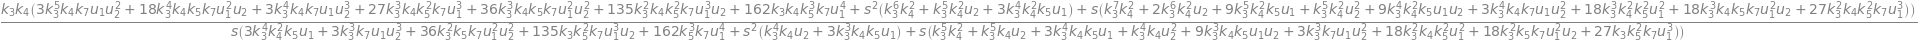

In [40]:
G_human

In [41]:
alpha = sp.simplify(b1/b2)
beta  = sp.simplify(b0/b2)

a2t = sp.simplify(a2/b2)
a1t = sp.simplify(a1/b2)
a0t = sp.simplify(a0/b2)

G_norm = (k3*k4/s) * (a2t*s**2 + a1t*s + a0t)/(s**2 + alpha*s + beta)

print("alpha =", sp.factor(alpha))
print("beta  =", sp.factor(beta))
sp.pprint(sp.factor(G_norm))


alpha = (k3**4*k4**2 + k3**4*k4*u2 + 3*k3**3*k4*k5*u1 + k3**3*k4*u2**2 + 9*k3**2*k4*k5*u1*u2 + 3*k3**2*k7*u1*u2**2 + 18*k3*k4*k5**2*u1**2 + 18*k3*k5*k7*u1**2*u2 + 27*k5**2*k7*u1**3)/(k3**2*k4*(k3*u2 + 3*k5*u1))
beta  = 3*u1*(k3**4*k4**2*k5 + k3**3*k7*u2**3 + 12*k3**2*k5*k7*u1*u2**2 + 45*k3*k5**2*k7*u1**2*u2 + 54*k5**3*k7*u1**3)/(k3**3*k4*(k3*u2 + 3*k5*u1))
                                                                               ↪
                                                                               ↪
────────────────────────────────────────────────────────────────────────────── ↪
  ⎛  5   2       5               4   2             4                4     2    ↪
s⋅⎝k₃ ⋅k₄ ⋅s + k₃ ⋅k₄⋅s⋅u₂ + 3⋅k₃ ⋅k₄ ⋅k₅⋅u₁ + 3⋅k₃ ⋅k₄⋅k₅⋅s⋅u₁ + k₃ ⋅k₄⋅s ⋅u₂ ↪

↪        2   2 ⎛  2                         ⎞ ⎛  4          3               2  ↪
↪      k₃ ⋅k₄ ⋅⎝k₃  + k₃⋅s + k₃⋅u₂ + 6⋅k₅⋅u₁⎠⋅⎝k₃ ⋅k₄⋅s + k₃ ⋅k₄⋅s⋅u₂ + 3⋅k₃ ⋅ ↪
↪ ───────────────────────────────────────────────────────────────────────

## Workflow

In [63]:
import sympy as sp

def tf_from_error(f, x, r, y_expr, uc_expr, s, cancel=True):
    """
    f: sympy Matrix drift f(x,r)
    x: sympy Matrix state vector
    r: sympy Symbol reference
    y_expr: sympy expression for y
    uc_expr: sympy expression for u_c (actuation rate)
    """
    A = f.jacobian(x)
    B = f.diff(r)  # column

    Cy = sp.Matrix([[sp.diff(y_expr, xi) for xi in x]])   # 1xn
    Cu = sp.Matrix([[sp.diff(uc_expr, xi) for xi in x]])  # 1xn

    Ae = A + B*Cy  # for e = r - y

    I = sp.eye(len(x))
    X = (s*I - Ae).LUsolve(B)      # (sI-Ae)^{-1} B
    if cancel:
        G = sp.cancel(sp.together((Cu*X)[0]))
    else:
        G = sp.together((Cu*X)[0])

    return sp.simplify(G), A, B, Cy, Cu

def quad_coeffs(expr, s):
    """Given a rational expr, return numerator/denominator Poly coeff lists."""
    expr = sp.cancel(sp.together(expr))
    P, Q = sp.fraction(expr)
    Pp, Qp = sp.Poly(P, s), sp.Poly(Q, s)
    return Pp, Qp


import sympy as sp

def s_order(poly_expr, s):
    """
    Return the largest integer m such that s^m divides poly_expr (a polynomial in s).
    """
    poly = sp.Poly(poly_expr, s)
    if poly.is_zero:
        return sp.oo
    d = poly.as_dict()  # maps monom exponents -> coeff
    # exponent is a tuple like (k,) for s^k
    return min(exp[0] for exp in d.keys())

def factor_out_s(G, s, cancel=True):
    """
    Return (m, Gred) where G = s^{-m} * Gred and Gred has no pole at 0.
    m > 0 means pole of order m at s=0.
    """
    if cancel:
        G = sp.cancel(sp.together(G))   
    else:
        G = sp.together(G)
    P, Q = sp.fraction(G)

    # Orders of s in numerator and denominator polynomials
    ordP = s_order(P, s)
    ordQ = s_order(Q, s)

    m = ordQ - ordP  # pole order at 0 (can be 0,1,2,...)

    # Remove that pole by multiplying by s^m
    Gred = sp.cancel(sp.together(G * (s**m)))
    return int(m), Gred

import sympy as sp

def tf_siso_det(Ae, B, C, s):
    """
    Returns (num, den) polynomials such that G(s) = num/den,
    for state-space: xdot = Ae x + B u, y = C x  (D=0), SISO.
    Uses determinant formula with Berkowitz.
    """
    n = Ae.shape[0]
    I = sp.eye(n)

    M = s*I - Ae

    den = sp.factor_terms(M.det(method='berkowitz'))  # det(sI-A)

    # Rosenbrock block matrix
    top = sp.Matrix.hstack(M, B)
    bottom = sp.Matrix.hstack(-C, sp.Matrix([[0]]))
    R = sp.Matrix.vstack(top, bottom)

    num = sp.factor_terms(R.det(method='berkowitz'))

    # num/den equals C(sI-A)^{-1}B for this construction
    return sp.together(num), sp.together(den)

def poly_coeffs(expr, s):
    p = sp.Poly(expr, s, domain='EX')
    return p.degree(), p.all_coeffs()


In [64]:
s = sp.Symbol('s')
k3,k4,k5,k7,u2,r = sp.symbols('k3 k4 k5 k7 u2 r', positive=True)

X,Z1,Z3 = sp.symbols('X Z1 Z3', positive=True)
x = sp.Matrix([X,Z1,Z3])

# Drift f(x,r) for network B
f = sp.Matrix([
    k4*Z1 + k7*Z1*Z3 - (u2+k3)*X - k5*X**2,
    k3*r - k7*Z1*Z3,
    k3*X - k7*Z1*Z3
])

y_expr  = X
uc_expr = k4*Z1 + k7*Z1*Z3

G, A, B, Cy, Cu = tf_from_error(f, x, r, y_expr, uc_expr, s)

m, Gred = factor_out_s(G, s)
print("pole order at s=0:", m)   # should be 1 for integral action

Pp, Qp = quad_coeffs(Gred, s)
print("Gred numerator degree:", Pp.degree(), "den degree:", Qp.degree())

print(sp.factor(G))

# If Gred is quadratic/quadratic, print coefficients
a = Pp.all_coeffs()
b = Qp.all_coeffs()
print("Numerator coefficients:", [sp.factor(ci) for ci in a])
print("Denominator coefficients:", [sp.factor(ci) for ci in b])

# Low-frequency gains from structured form:
# If G = (K/s) * (a2 s^2 + a1 s + a0)/(b2 s^2 + b1 s + b0)
# then Ki = K * a0/b0 and Kp = K*(a1/b0 - a0*b1/b0^2)



pole order at s=0: 1
Gred numerator degree: 2 den degree: 2
k3*(Z1*k4*k7 + Z3*k7*s + k4*s)*(2*X*k5 + k3 + s + u2)/(s*(2*X*Z1*k5*k7 + 2*X*Z3*k5*k7 + 2*X*k5*s + Z1*k7*s + Z1*k7*u2 + Z3*k7*s + Z3*k7*u2 - k3*k4 + k3*s + s**2 + s*u2))
Numerator coefficients: [k3*(Z3*k7 + k4), k3*(2*X*Z3*k5*k7 + 2*X*k4*k5 + Z1*k4*k7 + Z3*k3*k7 + Z3*k7*u2 + k3*k4 + k4*u2), Z1*k3*k4*k7*(2*X*k5 + k3 + u2)]
Denominator coefficients: [1, 2*X*k5 + Z1*k7 + Z3*k7 + k3 + u2, 2*X*Z1*k5*k7 + 2*X*Z3*k5*k7 + Z1*k7*u2 + Z3*k7*u2 - k3*k4]


deg(num) = 3
deg(den) = 4
num coeffs: [Z3*k3*k7 + k3*k4, 2*X*Z3*k3*k5*k7 + 2*X*Z3*k3*k6*k7 + 2*X*k3*k4*k5 + 2*X*k3*k4*k6 + Z1*k3*k4*k7 + 4*Z2*Z3*k3*k7*k8 + 4*Z2*k3*k4*k8 + Z3*k3**2*k7 + Z3*k3*k7*u2 + k3**2*k4 + k3*k4*u2, 2*X*Z1*k3*k4*k5*k7 + 2*X*Z1*k3*k4*k6*k7 + 8*X*Z2*Z3*k3*k5*k7*k8 + 8*X*Z2*Z3*k3*k6*k7*k8 + 8*X*Z2*k3*k4*k5*k8 + 8*X*Z2*k3*k4*k6*k8 + 4*Z1*Z2*k3*k4*k7*k8 + Z1*k3**2*k4*k7 + Z1*k3*k4*k7*u2 + 4*Z2*Z3*k3**2*k7*k8 + 4*Z2*Z3*k3*k7*k8*u2 + 4*Z2*k3**2*k4*k8 + 4*Z2*k3*k4*k8*u2, 8*X*Z1*Z2*k3*k4*k5*k7*k8 + 8*X*Z1*Z2*k3*k4*k6*k7*k8 + 4*Z1*Z2*k3**2*k4*k7*k8 + 4*Z1*Z2*k3*k4*k7*k8*u2]
den coeffs: [1, 2*X*k5 + 2*X*k6 + Z1*k7 + 4*Z2*k8 + Z3*k7 + k3 + u2, 2*X*Z1*k5*k7 + 2*X*Z1*k6*k7 + 8*X*Z2*k5*k8 + 8*X*Z2*k6*k8 + 2*X*Z3*k5*k7 + 2*X*Z3*k6*k7 + 4*Z1*Z2*k7*k8 + Z1*k7*u2 + 4*Z2*Z3*k7*k8 + 4*Z2*k3*k8 + 4*Z2*k8*u2 + Z3*k7*u2 - k3*k4, 8*X*Z1*Z2*k5*k7*k8 + 4*X*Z1*Z2*k6*k7*k8 + 8*X*Z2*Z3*k5*k7*k8 + 4*X*Z2*Z3*k6*k7*k8 - 4*X*Z2*k4*k6*k8 + 4*Z1*Z2*k7*k8*u2 + 4*Z2*Z3*k7*k8*u2 - 4*Z2*k3*k4*k8, 0]
G_c

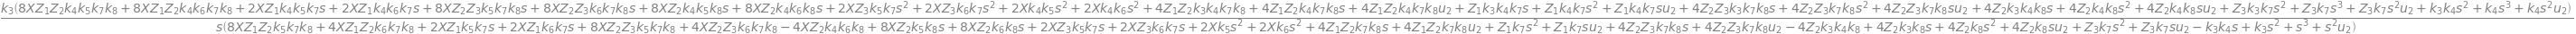

In [68]:
import sympy as sp

# symbols
s = sp.Symbol('s')
k3,k4,k5,k6,k7,k8,u2,r = sp.symbols('k3 k4 k5 k6 k7 k8 u2 r', positive=True)

X,Z1,Z2,Z3 = sp.symbols('X Z1 Z2 Z3', positive=True)
xA = sp.Matrix([X,Z1,Z2,Z3])

# vector field fA(x,r)
fA = sp.Matrix([
    k4*Z1 + k7*Z1*Z3 - (u2+k3)*X - (k5+k6)*X**2,
    k3*r + k8*Z2**2 - k7*Z1*Z3,
    k6*X**2 - 2*k8*Z2**2,
    k3*X + k8*Z2**2 - k7*Z1*Z3
])

# outputs
y_expr  = X
uc_expr = k4*Z1 + k7*Z1*Z3

# linearization pieces
A = fA.jacobian(xA)   # 4x4
B = fA.diff(r)        # 4x1

Cy = sp.Matrix([[sp.diff(y_expr, xi) for xi in xA]])    # 1x4  (here [1,0,0,0])
Cu = sp.Matrix([[sp.diff(uc_expr, xi) for xi in xA]])   # 1x4

# error injection (Method 1) for e = r - y
Ae = A + B*Cy

# determinant-based transfer function
num, den = tf_siso_det(Ae, B, Cu, s)
G = sp.together(num/den)

# polynomial degrees and coefficients in s
degN = sp.Poly(num, s, domain='EX').degree()
degD = sp.Poly(den, s, domain='EX').degree()

a = sp.Poly(num, s, domain='EX').all_coeffs()
b = sp.Poly(den, s, domain='EX').all_coeffs()

print("deg(num) =", degN)
print("deg(den) =", degD)
print("num coeffs:", a)
print("den coeffs:", b)

u1 = sp.Symbol('u1', positive=True)
G_u1 = sp.simplify(G.subs({r: 3*u1/k3}))
print("G_ce(s) =")
G_u1


deg(num3) = 3 deg(den3) = 3
   ⎛                                                                           ↪
k₃⋅⎝8⋅X⋅Z₁⋅Z₂⋅k₄⋅k₅⋅k₇⋅k₈ + 8⋅X⋅Z₁⋅Z₂⋅k₄⋅k₆⋅k₇⋅k₈ + 4⋅Z₁⋅Z₂⋅k₃⋅k₄⋅k₇⋅k₈ + 4⋅Z₁ ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                          ⎛                                    ↪
                                        s⋅⎝8⋅X⋅Z₁⋅Z₂⋅k₅⋅k₇⋅k₈ + 4⋅X⋅Z₁⋅Z₂⋅k₆⋅k ↪

↪                    3                 2                                       ↪
↪ ⋅Z₂⋅k₄⋅k₇⋅k₈⋅u₂ + s ⋅(Z₃⋅k₇ + k₄) + s ⋅(2⋅X⋅Z₃⋅k₅⋅k₇ + 2⋅X⋅Z₃⋅k₆⋅k₇ + 2⋅X⋅k₄ ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪
↪ ₇⋅k₈ + 8⋅X⋅Z₂⋅Z₃⋅k₅⋅k₇⋅k₈ + 4⋅X⋅Z₂⋅Z₃⋅k₆⋅k₇⋅k₈ - 4⋅X⋅Z₂⋅k₄⋅k₆⋅k₈ + 4⋅Z₁⋅Z₂⋅k ↪

↪                                                                              ↪
↪ ⋅k₅ + 2⋅X⋅k₄⋅k₆ + Z₁⋅k₄⋅k₇ + 4⋅Z₂⋅Z₃⋅k₇⋅k₈ + 4⋅Z₂⋅k₄⋅k₈ + Z₃⋅k₃⋅k₇ + Z₃⋅k₇⋅u 

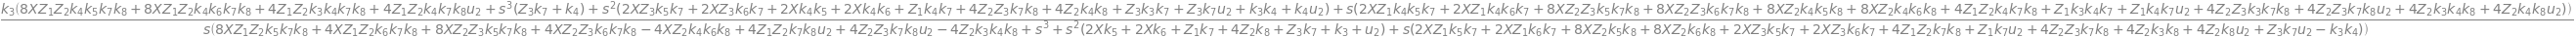

In [ ]:
# num, den are the polynomials you got from tf_siso_det
numP = sp.Poly(num, s, domain='EX')
denP = sp.Poly(den, s, domain='EX')

# Factor out the integrator: den = s * den3
den3 = sp.cancel(den / s)

num3P = sp.Poly(num, s, domain='EX')     # degree 3
den3P = sp.Poly(den3, s, domain='EX')    # should be degree 3

print("deg(num3) =", num3P.degree(), "deg(den3) =", den3P.degree())

# Now write
# G(s) = num(s)/den(s) = (num3(s)) / (s*den3(s))
G_pretty = sp.together(num3P.as_expr() / (s*den3P.as_expr()))
sp.pprint(G_pretty)

# Coefficients of the reduced cubic/cubic filter
a3 = num3P.all_coeffs()     # [a3, a2, a1, a0]
b3 = den3P.all_coeffs()     # [1, b2, b1, b0] typically

print("a (num coeffs):", [sp.factor_terms(ci) for ci in a3])
print("b (den coeffs):", [sp.factor_terms(ci) for ci in b3])

# Optional: normalize den3 to be monic (leading coefficient 1)
lead = b3[0]
numN = sp.together(num3P.as_expr()/lead)
denN = sp.together(den3P.as_expr()/lead)
G_norm = sp.together(numN/(s*denN))



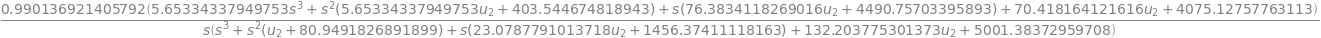

In [78]:
# substitutions for equilibrium values

vals_params = {
    k3: 0.9901369214057922,
    k4: 0.9587675929069519,
    k5: 1.1058326959609985,
    k6: 1.7381806373596191,
    k7: 1.173643946647644,
    k8: 1.564497947692871,
    # u2: 1.0,
}

vals_eq = {
    X:  10.0,   # Xst
    Z1: 5.0,
    Z2: 2.0,
    Z3: 4.0
}

vals = {**vals_params, **vals_eq}

G_num = sp.together(G_norm.subs(vals))
# convert to float form (optional)
G_num = sp.N(G_num)
G_num

In [79]:
u2_val = 1.0
G_u2 = sp.N(G_num.subs({u2: u2_val}))

num_u2, den_u2 = sp.fraction(sp.together(G_u2))
# remove integrator pole at 0:
den3_u2 = sp.together(den_u2 / s)

poles = sp.nroots(den3_u2)
zeros = sp.nroots(num_u2)

print("integrator pole: 0")
print("other poles:", poles)
print("zeros:", zeros)


integrator pole: 0
other poles: [-57.9467934602459, -19.4468156828231, -4.55557354612086]
zeros: [-58.8704035878182, -12.5159835815430, -0.995209123275641]


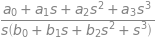

In [76]:
import sympy as sp

# coefficients (highest -> lowest)
a3_expr, a2_expr, a1_expr, a0_expr = num3P.all_coeffs()
b3_expr, b2_expr, b1_expr, b0_expr = den3P.all_coeffs()  # b3 should be 1 if monic

# create *symbolic* coefficient names
a3,a2,a1,a0 = sp.symbols('a3 a2 a1 a0')
b2,b1,b0    = sp.symbols('b2 b1 b0')     # (omit b3 since it's typically 1)

# masked transfer function: G(s) = (a3 s^3 + a2 s^2 + a1 s + a0) / (s*(s^3 + b2 s^2 + b1 s + b0))
G_masked = (a3*s**3 + a2*s**2 + a1*s + a0) / (s*(s**3 + b2*s**2 + b1*s + b0))

G_masked
